# IPL Batting Analysis
Examining run-scoring patterns, strike rates, death-over performance, and player
consistency using ball-by-ball data (2008–2024).

## 1. Setup

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

delivery = pd.read_csv("../Resources/deliveries.csv")
merged = pd.read_csv("../Resources/merged_data.csv")

## 2. Top Run-Scorers (All Time)
Who has scored the most runs across IPL history? A simple but essential baseline
before diving into rate-based stats.

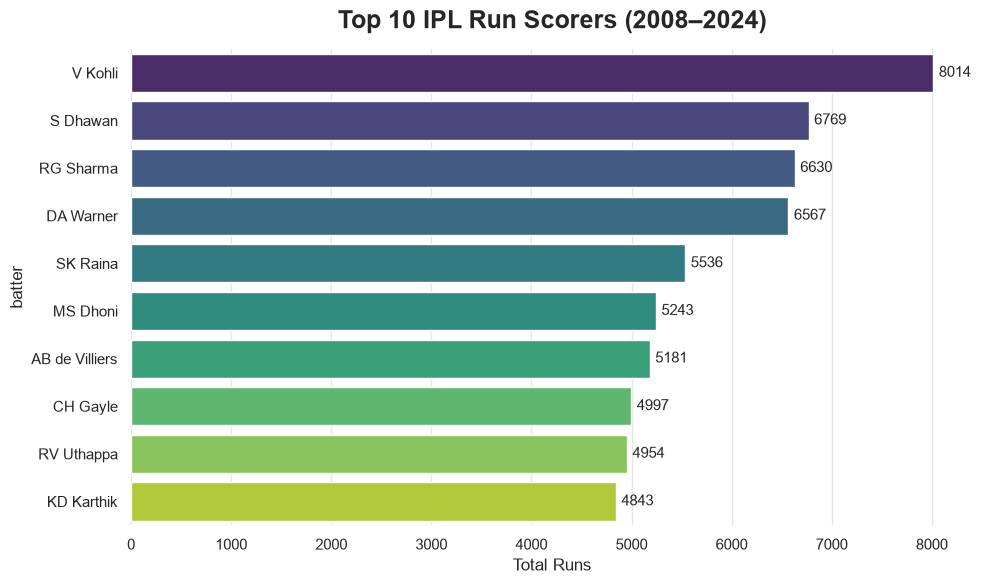

In [2]:
runs = delivery.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
ax = sns.barplot(x=runs.values, y=runs.index, palette='viridis', hue = runs.index, legend=False)
for container in ax.containers:
    ax.bar_label(container, fontsize = 11, padding=4)
plt.title(
    "Top 10 IPL Run Scorers (2008–2024)",
    fontsize=18,
    weight='bold',
    pad=15
)
sns.despine(left=True, bottom=True)
plt.xlabel('Total Runs')
plt.tight_layout()
plt.savefig('../charts/top_run_scorers.png')
plt.show()

## 3. Highest Strike Rates (Min 500 Balls Faced)
Total runs rewards longevity — strike rate shows who scores fastest. Filtering to
500+ balls faced so small sample sizes don't distort the list.

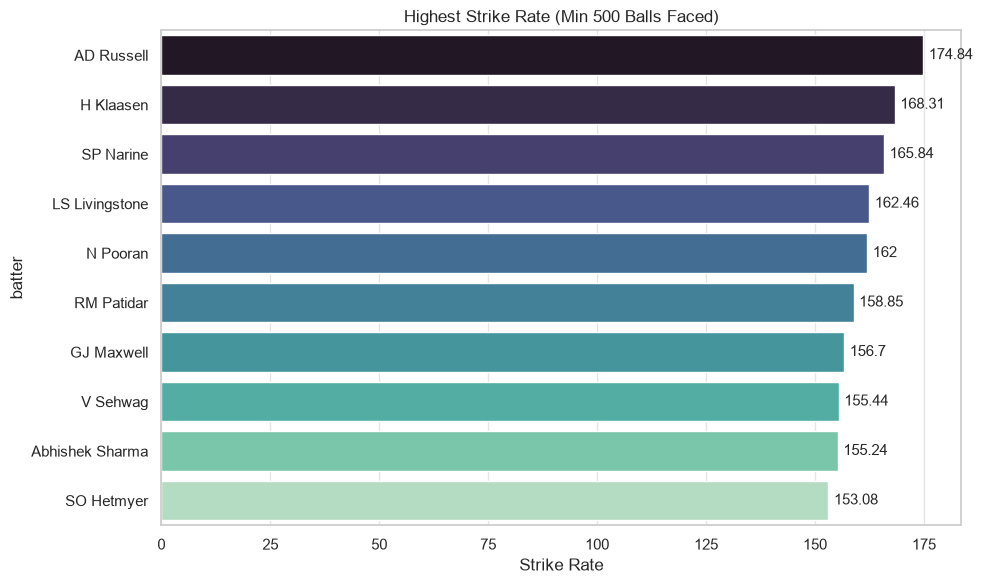

In [3]:
legal_deliveries = delivery[delivery['extras_type'] != 'wides']
balls_faced = legal_deliveries.groupby('batter')['ball'].count()
total_runs = delivery.groupby('batter')['batsman_runs'].sum()

sr = (total_runs / balls_faced * 100).round(2)
qualified = sr[balls_faced >= 500].sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
bx = sns.barplot(x=qualified.values, y=qualified.index, palette='mako', hue = runs.index, legend=False)
for container in bx.containers:
    bx.bar_label(container, fontsize = 11, padding=4)
plt.title('Highest Strike Rate (Min 500 Balls Faced)')
plt.xlabel('Strike Rate')
plt.tight_layout()
plt.savefig("../charts/higest_strike_rate.png")
plt.show()

**Observations:**
- AD Russel has the highest strike rate at 174.85.
- This list doesn't overlap with the run-scorers list, showing volume and speed are different skills

## 4. Best Finishers (Death Overs 17–20)
Death-over batting is a specialised skill under maximum pressure. Filtering to 100+
balls faced in overs 17-20 to ensure a meaningful sample.

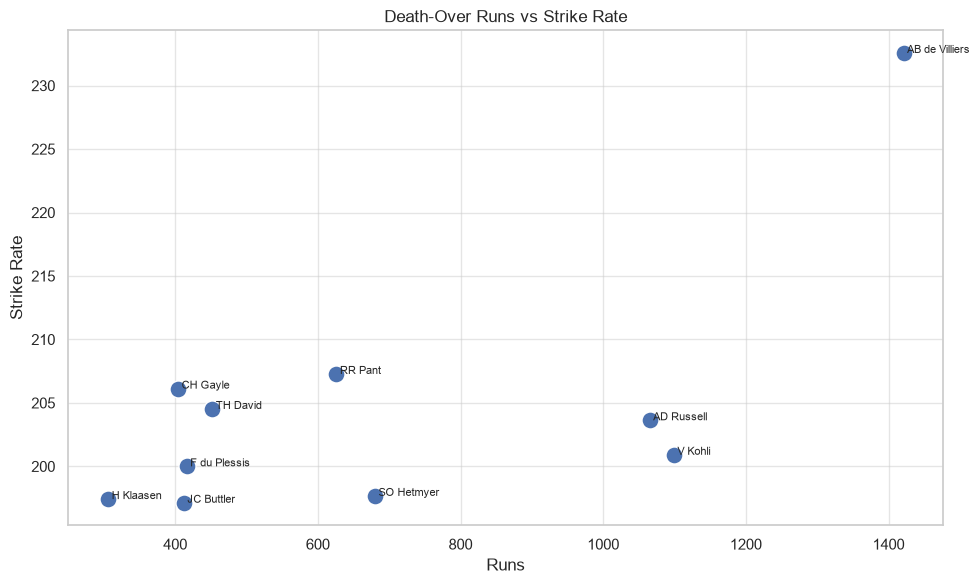

In [4]:
death_overs = delivery[(delivery['over'] >= 16) & (delivery['extras_type'] != 'wides')]  # overs 17-20 are index 16-19

death_runs = death_overs.groupby('batter')['batsman_runs'].sum()
death_balls = death_overs.groupby('batter')['ball'].count()
dismissal_types = ['caught','bowled','lbw','stumped','caught and bowled','hit wicket']
death_dismissals = (death_overs[death_overs['dismissal_kind'].isin(dismissal_types)].groupby('player_dismissed').size())

death_avg = (death_runs / death_dismissals.replace(0, pd.NA)).round(2)
death_sr = (death_runs / death_balls * 100).round(2)

finishers = pd.DataFrame({'runs': death_runs, 'average': death_avg, 'strike_rate': death_sr, "balls" : death_balls})
finishers = finishers[finishers["balls"] >= 100]
finishers = finishers.sort_values(["strike_rate","runs", "average"], ascending=[False,False,False]).head(10)

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=finishers,
    x="runs",
    y="strike_rate",
    s=150
)
for batter in finishers.index:
    plt.text(finishers.loc[batter, "runs"] + 5,finishers.loc[batter, "strike_rate"],batter,fontsize=8)

plt.title("Death-Over Runs vs Strike Rate")
plt.xlabel("Runs")
plt.ylabel("Strike Rate")

plt.tight_layout()
plt.savefig("../charts/best_finishers.png")
plt.show()

**Observations:**
- AB deVilliers is the standout finisher with more than 1400 runs AND 230+ strike rate in death overs,
  balancing both metrics rather than excelling at just one
- He is the player with far greater striker and runs than any other player

## 6. Player Consistency Score (Mean vs Median)
Among the top 10 run-scorers, who scores consistently match after match versus who
relies on a few standout innings to inflate their average? A large gap between mean
and median signals inconsistency — a handful of big scores pulling the mean up while
the median (the "typical" game) stays low.

,batter,innings,mean,std_dev,cv
0,MS Dhoni,228,23.00,18.28,0.795
1,DA Warner,184,35.69,28.97,0.812
2,S Dhawan,221,30.63,25.38,0.828
3,V Kohli,244,32.84,27.47,0.836
4,SK Raina,200,27.68,23.22,0.839
5,RV Uthappa,197,25.15,21.16,0.841
6,KD Karthik,233,20.79,18.74,0.902
7,RG Sharma,251,26.41,23.92,0.906
8,AB de Villiers,170,30.48,27.63,0.907
9,CH Gayle,141,35.44,33.14,0.935


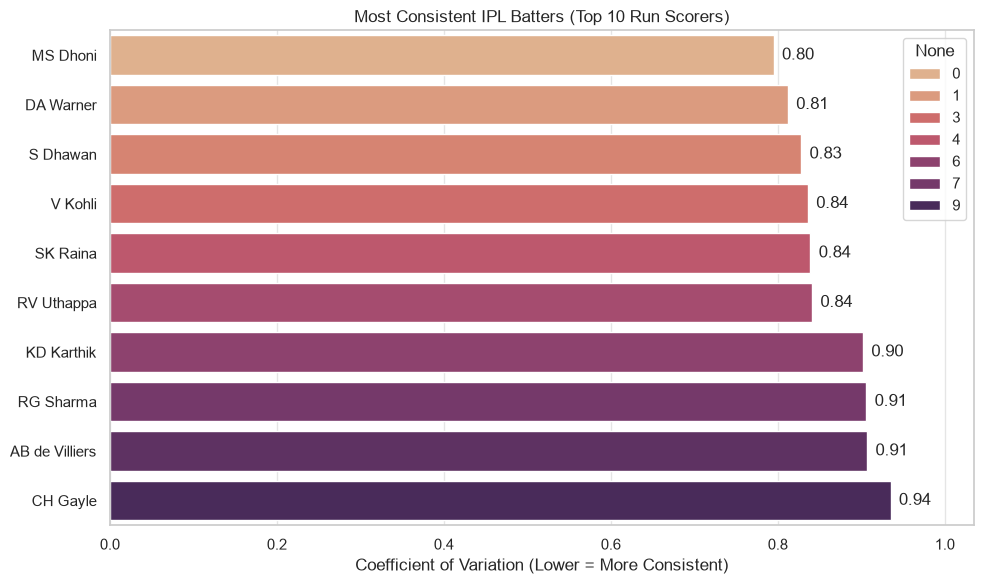

In [5]:
# Top 10 run scorers
top10_batters = runs.index
consistency = []
for player in top10_batters:
    scores = (delivery[delivery['batter'] == player].groupby('match_id')['batsman_runs'].sum())
    mean = scores.mean()
    std = scores.std()
    consistency.append({
        "batter": player,
        "innings": scores.count(),
        "mean": round(mean, 2),
        "std_dev": round(std, 2),
        "cv": round(std / mean, 3)
    })
consistency_df = (
    pd.DataFrame(consistency)
    .sort_values("cv")
    .reset_index(drop=True)
)
display(consistency_df)

plt.figure(figsize=(10, 6))

sns.barplot(data=consistency_df,x="cv",y="batter",palette="flare", hue = consistency_df.index)
# Annotate CV values
for i, value in enumerate(consistency_df["cv"]):
    plt.text(value + 0.01, i, f"{value:.2f}", va="center")

plt.xlabel("Coefficient of Variation (Lower = More Consistent)")
plt.ylabel("")
plt.title("Most Consistent IPL Batters (Top 10 Run Scorers)")
plt.xlim(0, consistency_df["cv"].max() + 0.1)

plt.tight_layout()
plt.savefig("../charts/Bastmen_consistency_cv.png", dpi=300)
plt.show()

**Observations:**
- MS Dhoni has the smallest gap (5342 runs), making them the most consistent run-scorer
  in the top 10 — closer to a guaranteed contribution every match
- CH Gayle has the largest mean-median gap (4997 runs), meaning a few standout innings
  are propping up their average — their "typical" match output is much lower than it
  first appears
- All the top 10 run scorers are in the list of most consistent players

## Key Findings

1. V Kohli is the all-time leading run-scorer, but total runs and strike rate
   produce almost entirely different top-10 lists — volume and speed aren't the
   same skill.
2. AB Devilliers is the greatest death over specialist of all time with over 1400 runs in death overs and a strike rate of above 230
3. Mean-median gap analysis reveals that CH Gayle, despite high career totals, is
   actually one of the more inconsistent scorers — a few big innings are doing
   most of the work.
4. MS Dhoni emerges as the most consistent top-order batter in the dataset — low
   mean-median gap despite a high overall run total.